# Figure 1: CDF of belief about true news

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fit OLS on demeaned data with cluster-robust SE
from sklearn.linear_model import LinearRegression
from scipy import stats

import statsmodels.formula.api as smf

plt.style.use('default') # set default plotting style
plt.rcParams['figure.figsize'] = (10, 6) # set figure size
plt.rcParams['font.size'] = 12 # set font size

This cell imports the required Python libraries: pandas for data manipulation, numpy for numerical operations, and matplotlib for visualization.
These libraries are essential for loading the dataset, processing variables, and plotting the empirical cumulative distribution functions (ECDFs).

In [2]:
# Path to dataset
data_path = 'data/cleaned_data.csv'
# Load dataset into DataFrame
df = pd.read_csv(data_path)
# Preview first 5 rows
df.head()

,id_in_session,code,index_in_pages,current_page_name,time_started,payoff,consent,treatment,age_temp,gender,...,mean_prob_rep_temp,mean_prob_rep,mean_prob_dem_temp,mean_prob_dem,mean_prob_net,mean_prob_net_mean,mean_prob_net_sd,mean_prob_net_z,out_of_range_q,out_of_range
0,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
1,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
2,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,0.7,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
3,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,0.516667,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
4,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0


This cell loads the cleaned dataset from a CSV file and previews the first few rows. We need to inspect the structure of the dataset and confirm that all required variables (e.g., prob_true, good_news, bad_news) are present before proceeding.

In [3]:
# Filter to the same sample used by the Stata code for Figure 1
mask = (
    ((df['good_news'] + df['bad_news']) > 0)
    & ((df['pro_party'] + df['anti_party']) > 0)
)
sub = df.loc[mask].copy()

# Group labels used for plotting
sub['news_type'] = np.where(sub['good_news'] == 1, 'Pro-Party News', 'Anti-Party News')

sub['prob_true'] = pd.to_numeric(sub['prob_true'], errors='coerce')
sub = sub.dropna(subset=['prob_true'])

sub['news_type'].value_counts()

news_type
Anti-Party News    3961
Pro-Party News     3941
Name: count, dtype: int64

Filter Sample and Prepare Variables
This cell filters the dataset to match the sample used in the original Stata Figure 1 and creates the `news_type` variable. 
We restrict the sample to observations that contain valid political news (pro-party or anti-party) and valid news classification (good or bad news).  
We also create a clean categorical variable for grouping and ensure `prob_true` is numeric for plotting.

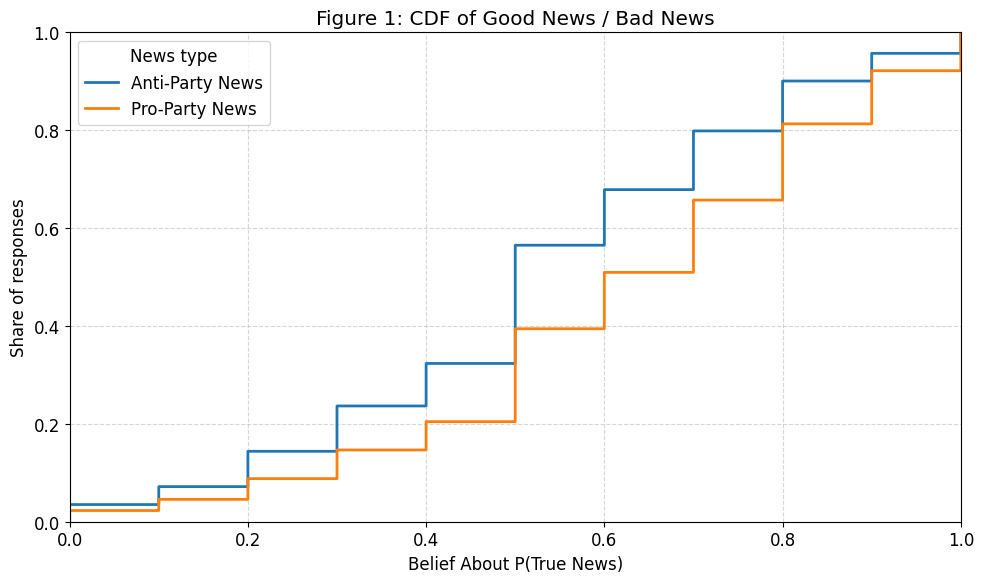

In [4]:
# Function to compute ECDF
def ecdf(series):
    x = np.sort(series)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# Create figure
plt.figure(figsize=(10, 6))
for label, group in sub.groupby('news_type'):
    x, y = ecdf(group['prob_true'])
    plt.step(x, y, where='post', label=label, linewidth=2)
# Label axes
plt.xlabel('Belief About P(True News)')
plt.ylabel('Share of responses')
# Title and legend
plt.title('Figure 1: CDF of Good News / Bad News')
plt.legend(title='News type')
# Axis limits
plt.xlim(0, 1)
plt.ylim(0, 1)
# Grid for readability
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout() # adjust layout
plt.show() # display plot

Plot ECDF for Each News Type
This cell plots the ECDF of `prob_true` separately for Pro-Party and Anti-Party news.
This visualization replicates Figure 1 by comparing how beliefs differ across news types.  
The step plot is used to match the style of cumulative distribution functions.

# Figure 3: Demeaned Beliefs About the Probability that News is True by Political Alignment and News

In [5]:
# Convert to numeric
cols = ["prob_true", "anti_party", "pro_party", "good_news", "bad_news"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep rows used in this figure
plot_df = df.dropna(subset=cols).copy()


This cell prepares the dataset for Figure 3 by converting key variables into a numerical format and filtering the observations used for analysis. The formatting of variables, such as `prob_true` (true probability) and various political indicators aims to ensure the validity and consistency of statistical calculations. The filtering step eliminates missing values, retaining only those observations containing valid classifications of "good news" or "bad news." This preprocessing step is crucial for constructing a clean and comparable set of groupings, thereby laying the foundation for the bar chart visualization in Figure 3—a figure designed to analyze the patterns of belief divergence across different political stances and truthfulness categories.

In [6]:
# Only keep good news / bad news
plot_df = plot_df[
    (plot_df["good_news"] + plot_df["bad_news"] > 0)
].copy()

plot_df["group"] = pd.Series(pd.NA, index=plot_df.index, dtype="object")

# Anti-party
plot_df.loc[
    (plot_df["anti_party"] == 1) & (plot_df["politicized_true"] == 0),
    "group"
] = "Anti-Party,\nFake News"

plot_df.loc[
    (plot_df["anti_party"] == 1) & (plot_df["politicized_true"] == 1),
    "group"
] = "Anti-Party,\nTrue News"

# Neutral
plot_df.loc[
    (plot_df["anti_party"] == 0) &
    (plot_df["pro_party"] == 0) &
    (plot_df["fake_news"] == 1),
    "group"
] = "Neutral,\nFake News"

plot_df.loc[
    (plot_df["anti_party"] == 0) &
    (plot_df["pro_party"] == 0) &
    (plot_df["true_news"] == 1),
    "group"
] = "Neutral,\nTrue News"

# Pro-party
plot_df.loc[
    (plot_df["pro_party"] == 1) & (plot_df["politicized_true"] == 0),
    "group"
] = "Pro-Party,\nFake News"

plot_df.loc[
    (plot_df["pro_party"] == 1) & (plot_df["politicized_true"] == 1),
    "group"
] = "Pro-Party,\nTrue News"

plot_df = plot_df.dropna(subset=["group"]).copy()

print(plot_df["group"].value_counts())

group
Anti-Party,\nTrue News    2624
Pro-Party,\nFake News     2592
Pro-Party,\nTrue News     1349
Anti-Party,\nFake News    1337
Neutral,\nFake News        509
Neutral,\nTrue News        471
Name: count, dtype: int64


This cell filters the dataset to retain only those observations relevant to the analysis, and constructs a categorical grouping variable. This grouping variable encompasses both political stance and the veracity of the news content, thereby enabling the data to be segmented into substantively meaningful categories for comparative analysis within the final visualization.

In [7]:
# Define order of groups
group_order = [
    "Anti-Party,\nFake News",
    "Anti-Party,\nTrue News",
    "Neutral,\nFake News",
    "Neutral,\nTrue News",
    "Pro-Party,\nFake News",
    "Pro-Party,\nTrue News"
]

# Compute overall mean
overall_mean = plot_df["prob_true"].mean()

# Compute group-level statistics
summary = (
    plot_df
    .groupby("group")["prob_true"]
    .agg(["mean", "count", "std"])
    .reindex(group_order)
    .reset_index()
)

# Compute demeaned mean, standard error, and 95% confidence interval
summary["demeaned_mean"] = summary["mean"] - overall_mean
summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]
print(summary)

                    group      mean  count       std  demeaned_mean        se  \
0  Anti-Party,\nFake News  0.545400   1337  0.249632      -0.031688  0.006827   
1  Anti-Party,\nTrue News  0.520579   2624  0.241429      -0.056509  0.004713   
2     Neutral,\nFake News  0.612967    509  0.260052       0.035878  0.011527   
3     Neutral,\nTrue News  0.586837    471  0.264569       0.009748  0.012191   
4   Pro-Party,\nFake News  0.635069   2592  0.246443       0.057981  0.004841   
5   Pro-Party,\nTrue News  0.590067   1349  0.238484       0.012978  0.006493   

       ci95  
0  0.013381  
1  0.009238  
2  0.022592  
3  0.023894  
4  0.009488  
5  0.012727  


This cell calculates summary statistics for each group, including the mean belief, sample size, and standard deviation. Additionally, it computes the mean of the demeaned values, the standard error, and the 95% confidence interval. These statistics are essential for constructing the bar chart and error bars displayed in the figure.

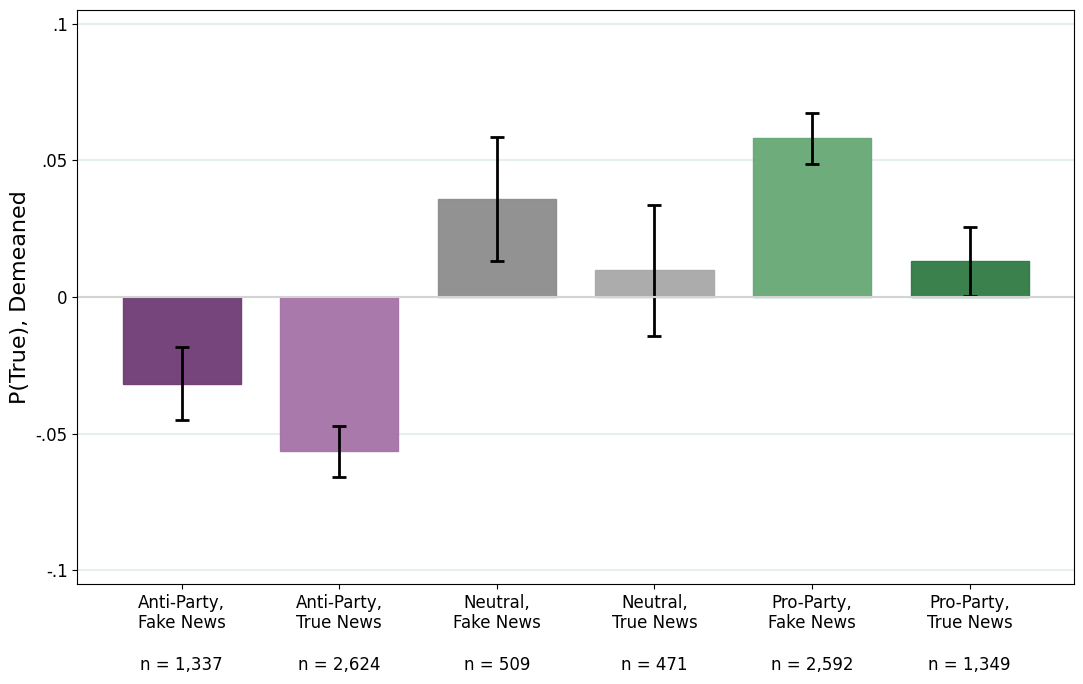

In [8]:
# Create x positions
x = np.arange(len(summary))

# Define colors
colors = [
    "#6f3b74",
    "#a672a7",
    "#8c8c8c",
    "#a8a8a8",
    "#66a875",
    "#2f7a44"
]

# Create labels with sample sizes
labels = [
    f"Anti-Party,\nFake News\n\nn = {int(summary.loc[0, 'count']):,}",
    f"Anti-Party,\nTrue News\n\nn = {int(summary.loc[1, 'count']):,}",
    f"Neutral,\nFake News\n\nn = {int(summary.loc[2, 'count']):,}",
    f"Neutral,\nTrue News\n\nn = {int(summary.loc[3, 'count']):,}",
    f"Pro-Party,\nFake News\n\nn = {int(summary.loc[4, 'count']):,}",
    f"Pro-Party,\nTrue News\n\nn = {int(summary.loc[5, 'count']):,}"
]

# Create figure
plt.figure(figsize=(11, 7))

# Draw bars
plt.bar(
    x,
    summary["demeaned_mean"],
    color=colors,
    edgecolor=colors,
    width=0.75,
    alpha=0.95
)

# Add error bars
plt.errorbar(
    x,
    summary["demeaned_mean"],
    yerr=summary["ci95"],
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    capthick=2
)

# Add horizontal reference line
plt.axhline(0, color="lightgray", linewidth=1.5)

# Customize x-axis
plt.xticks(x, labels, fontsize=12)

# Customize y-axis
plt.yticks(
    [-0.10, -0.05, 0, 0.05, 0.10],
    ["-.1", "-.05", "0", ".05", ".1"],
    fontsize=12
)

# Axis labels and limits
plt.ylabel("P(True), Demeaned", fontsize=16)
plt.ylim(-0.105, 0.105)

# Grid styling
plt.grid(axis="y", color="#e6eeee", linewidth=1.5)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

This cell generates the final bar chart, complete with confidence intervals. Each bar represents the mean-centered belief of a specific group regarding the probability that "the news is true," while the error bars reflect statistical uncertainty. This visualization replicates the structure of Figure 2 and highlights the differences across various political and information categories.

# Figure 4: Motivated reasoning by topic

In [9]:
# Filter to appropriate sample: net_party != 0
sub = df[df['net_party'] != 0].copy()

print(f"After filtering net_party != 0: {len(sub)} rows")
print(f"Unique codes (clusters): {sub['code'].nunique()}")

After filtering net_party != 0: 12558 rows
Unique codes (clusters): 897


This step filters the dataset to retain only those respondents who exhibit a clear political leaning (i.e., those who support or oppose a specific political party). The purpose of this filtering is to focus the analysis on individuals engaged in motivated reasoning, as neutral individuals would not exhibit directional bias. Furthermore, the code prints the number of remaining observations and the count of unique clusters; this information is crucial for the subsequent calculation of robust clustered standard errors.

In [10]:
# Identify good_topic columns (these already exist in the data)
good_topic_cols = [col for col in sub.columns if col.startswith('good_topic') and '_demeaned' not in col]
good_topic_cols = sorted(good_topic_cols, key=lambda x: int(x.replace('good_topic', '').replace('1415', '99')) if x != 'good_topic1415' else 99)

print(f"Found {len(good_topic_cols)} good_topic variables:")
print(good_topic_cols)

# Check data types and missing values
print(f"\nData types for first few good_topic cols:")
for col in good_topic_cols[:5]:
    print(f"  {col}: {sub[col].dtype}, missing: {sub[col].isna().sum()}")

Found 16 good_topic variables:
['good_topic1', 'good_topic2', 'good_topic3', 'good_topic4', 'good_topic5', 'good_topic6', 'good_topic7', 'good_topic8', 'good_topic9', 'good_topic10', 'good_topic11', 'good_topic12', 'good_topic13', 'good_topic14', 'good_topic15', 'good_topic1415']

Data types for first few good_topic cols:
  good_topic1: int64, missing: 0
  good_topic2: int64, missing: 0
  good_topic3: int64, missing: 0
  good_topic4: int64, missing: 0
  good_topic5: int64, missing: 0


By selecting columns prefixed with `good_topic`, the process identifies all variables within the dataset associated with "good topics," while simultaneously excluding variables that have already been mean-centered. These variables are then sorted numerically to ensure a consistent and interpretable ordering across topics. The objective is to dynamically extract all relevant topic indicators—without hard-coding specific variable names—thereby ensuring both scalability and consistency. Additionally, the code performs checks on data types and missing values ​​to verify that these variables are suitable for regression analysis.

In [11]:
# Prepare regression data
# Dependent variable: prob_true
# Independent variables: good_topic* indicators
# Fixed effects: round_number, topic_id (will be absorbed via demeaning)
# Cluster variable: code

y = sub['prob_true'].astype(float).values
X = sub[good_topic_cols].astype(float).values

print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")
print(f"Missing in y: {np.isnan(y).sum()}")
print(f"Missing in X: {np.isnan(X).sum()}")

y shape: (12558,)
X shape: (12558, 16)
Missing in y: 75
Missing in X: 0


Regression inputs are constructed by defining the dependent variable `y` as the perceived probability of news veracity (`prob_true`) and the independent variables `X` as a set of topic indicators. Both are converted into numerical arrays to ensure compatibility with the regression model. The objective is to prepare clean and structured inputs for estimation, while simultaneously validating dimensions and checking for missing values—steps that are crucial for avoiding errors and ensuring valid statistical results.

In [12]:
# Manual fixed effects demeaning
# Demean within each (round_number, topic_id) cell

sub_copy = sub.copy()
sub_copy['y'] = y

# Add X columns temporarily
for i, col in enumerate(good_topic_cols):
    sub_copy[f'X_{i}'] = X[:, i]

# Demean y and X within each FE group
# transform(lambda x: x - x.mean()) → within-group demeaning (fixed effects)
y_demeaned = sub_copy.groupby(['round_number', 'topic_id'])['y'].transform(lambda x: x - x.mean()).values

X_demeaned = X.copy()
for i, col in enumerate(good_topic_cols):
    X_demeaned[:, i] = sub_copy.groupby(['round_number', 'topic_id'])[f'X_{i}'].transform(lambda x: x - x.mean()).values

# Remove rows with NaN (from demeaning)
valid_idx = ~(np.isnan(y_demeaned) | np.isnan(X_demeaned).any(axis=1))
y_demeaned = y_demeaned[valid_idx]
X_demeaned = X_demeaned[valid_idx]

print(f"After demeaning:")
print(f"  y_demeaned shape: {y_demeaned.shape}")
print(f"  X_demeaned shape: {X_demeaned.shape}")

After demeaning:
  y_demeaned shape: (12483,)
  X_demeaned shape: (12483, 16)


This step accounts for fixed effects by manually demeaning both the dependent and independent variables within each (`round_number`, `topic_id`) group. By subtracting the group means, the model effectively controls for unobserved heterogeneity at the round and topic levels. The objective of this step is to replicate a fixed-effects regression without explicitly including dummy variables, thereby enhancing computational efficiency. Rows containing missing values ​​after the demeaning process are removed to ensure the validity of the regression sample.

In [13]:
# Fit model (no intercept since already demeaned)
model = LinearRegression(fit_intercept=False)
model.fit(X_demeaned, y_demeaned)

coef = model.coef_
y_pred = model.predict(X_demeaned)
residuals = y_demeaned - y_pred

print(f"Coefficients: {coef}")
print(f"Residual SS: {np.sum(residuals**2):.4f}")

Coefficients: [ 1.46495628e-01  9.91358115e-02  8.42268909e-02  6.10842256e-02
  1.08878627e-01  8.00619237e-02  1.05608429e-01  1.06640861e-02
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.38777878e-17
  6.50765779e-02  3.68741658e-02  4.82951179e-02  8.51692837e-02]
Residual SS: 685.9422


This step fits a linear regression model without an intercept using mean-centered variables, as the mean-centering process has already removed the mean structure. This model estimates the effect of each subject on the perceived probability of news authenticity. The objective of this step is to obtain baseline coefficient estimates and residuals, which will subsequently be used to calculate cluster-robust standard errors.

In [14]:
# Compute cluster-robust standard errors
# Get cluster assignment for non-dropped observations
clusters = sub[valid_idx]['code'].values
unique_clusters = np.unique(clusters)
n_clusters = len(unique_clusters)
n = len(y_demeaned)

# Drop zero-variance columns (these cause singular matrix)
col_variances = np.var(X_demeaned, axis=0)
nonzero_var_idx = col_variances > 1e-10
X_demeaned_clean = X_demeaned[:, nonzero_var_idx]
good_topic_cols_clean = [col for i, col in enumerate(good_topic_cols) if nonzero_var_idx[i]]

print(f"Dropped {(~nonzero_var_idx).sum()} zero-variance columns")

# Also drop perfect multicollinear columns using QR decomposition
Q, R = np.linalg.qr(X_demeaned_clean)
# Columns with very small diagonal in R are redundant
rank = np.sum(np.abs(np.diag(R)) > 1e-10)
X_demeaned_clean = X_demeaned_clean[:, :rank]
good_topic_cols_clean = good_topic_cols_clean[:rank]

print(f"After QR rank test, keeping {rank} columns: {good_topic_cols_clean}")

k = X_demeaned_clean.shape[1]

# Refit model on cleaned data
model = LinearRegression(fit_intercept=False)
model.fit(X_demeaned_clean, y_demeaned)
coef = model.coef_
y_pred = model.predict(X_demeaned_clean)
residuals = y_demeaned - y_pred

# Compute X'X inverse
XtX = X_demeaned_clean.T @ X_demeaned_clean
try:
    XtX_inv = np.linalg.inv(XtX)
except np.linalg.LinAlgError:
    print("XtX is still singular, using pseudoinverse")
    XtX_inv = np.linalg.pinv(XtX)

# Compute cluster-robust meat matrix
# For each cluster g: sum_g (X_g' * u_g) * (X_g' * u_g)'
meat = np.zeros((k, k))
for clust in unique_clusters:
    mask = clusters == clust
    X_c = X_demeaned_clean[mask]
    u_c = residuals[mask]
    Xu = X_c.T @ u_c  # (k,)
    meat += np.outer(Xu, Xu)  # (k, k)

# Cluster-robust VC: (n / n_clusters) * (X'X)^{-1} * meat * (X'X)^{-1}
vc_cluster = (n / n_clusters) * XtX_inv @ meat @ XtX_inv
se = np.sqrt(np.diag(vc_cluster))

# Compute 95% CI using t-distribution
df_resid = n - k
t_crit = stats.t.ppf(0.975, df_resid)
ci_lower = coef - t_crit * se
ci_upper = coef + t_crit * se

print(f"\nSample info:")
print(f"  n = {n}, k = {k}, n_clusters = {n_clusters}")
print(f"  df_resid = {df_resid}, t_crit(0.975) = {t_crit:.4f}")
print(f"\nResults (with cluster-robust SE):")
for i, col in enumerate(good_topic_cols_clean):
    print(f"  {col:20s}: coef={coef[i]:7.4f}, se={se[i]:7.4f}, 95% CI=[{ci_lower[i]:7.4f}, {ci_upper[i]:7.4f}]")

Dropped 4 zero-variance columns
After QR rank test, keeping 11 columns: ['good_topic1', 'good_topic2', 'good_topic3', 'good_topic4', 'good_topic5', 'good_topic6', 'good_topic7', 'good_topic8', 'good_topic13', 'good_topic14', 'good_topic15']

Sample info:
  n = 12483, k = 11, n_clusters = 897
  df_resid = 12472, t_crit(0.975) = 1.9602

Results (with cluster-robust SE):
  good_topic1         : coef= 0.1465, se= 0.0732, 95% CI=[ 0.0031,  0.2899]
  good_topic2         : coef= 0.0991, se= 0.0588, 95% CI=[-0.0161,  0.2143]
  good_topic3         : coef= 0.0842, se= 0.0592, 95% CI=[-0.0318,  0.2002]
  good_topic4         : coef= 0.0611, se= 0.0573, 95% CI=[-0.0511,  0.1733]
  good_topic5         : coef= 0.1089, se= 0.0609, 95% CI=[-0.0105,  0.2282]
  good_topic6         : coef= 0.0801, se= 0.0587, 95% CI=[-0.0351,  0.1952]
  good_topic7         : coef= 0.1056, se= 0.0580, 95% CI=[-0.0081,  0.2193]
  good_topic8         : coef= 0.0107, se= 0.0611, 95% CI=[-0.1090,  0.1304]
  good_topic13       

First, problematic columns are removed from the design matrix, including zero-variance variables and variables exhibiting perfect collinearity. Zero-variance columns are deleted because they provide no information useful for estimation, while QR decomposition is employed to detect and remove multicollinearity. The objective of this step is to ensure that the matrix inversion required for regression is numerically stable and well-defined.

Next, cluster-robust standard errors are computed to account for within-cluster correlations, utilizing a cluster identifier code. The variance-covariance matrix is ​​constructed using a sandwich estimator, from which the corresponding standard errors are derived. Confidence intervals are then calculated using the t-distribution. The purpose of this step is to facilitate valid statistical inference in the presence of clustered data, a common feature of survey or panel datasets.

In [15]:
# Create coefplot DataFrame
topic_labels = {
    'good_topic1': 'Pro-Party x Climate',
    'good_topic2': 'Pro-Party x Refugees',
    'good_topic3': 'Pro-Party x Obama crime',
    'good_topic4': 'Pro-Party x Gun laws',
    'good_topic5': 'Pro-Party x Race',
    'good_topic6': 'Pro-Party x Gender',
    'good_topic7': 'Pro-Party x Mobility',
    'good_topic8': 'Pro-Party x Media',
    'good_topic1415': 'Pro-Party x Party score',
    'good_topic13': 'Pro-Performance'
}

coef_df = pd.DataFrame({
    'topic': good_topic_cols_clean,
    'coef': coef,
    'se': se,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper
})

# Add labels
coef_df['label'] = coef_df['topic'].map(topic_labels)
coef_df['label'] = coef_df['label'].fillna(coef_df['topic'])  # Use topic name if no label

# Sort by coefficient value (for coefplot)
coef_df = coef_df.sort_values('coef').reset_index(drop=True)

print(coef_df[['topic', 'label', 'coef', 'ci_lower', 'ci_upper']])

           topic                    label      coef  ci_lower  ci_upper
0    good_topic8        Pro-Party x Media  0.010664 -0.109032  0.130360
1    good_topic4     Pro-Party x Gun laws  0.061084 -0.051138  0.173307
2   good_topic13          Pro-Performance  0.065077 -0.062413  0.192566
3    good_topic6       Pro-Party x Gender  0.080062 -0.035091  0.195215
4    good_topic3  Pro-Party x Obama crime  0.084227 -0.031754  0.200207
5    good_topic2     Pro-Party x Refugees  0.099136 -0.016055  0.214326
6    good_topic7     Pro-Party x Mobility  0.105608 -0.008117  0.219334
7    good_topic5         Pro-Party x Race  0.108879 -0.010478  0.228235
8   good_topic14             good_topic14  0.122043 -0.039891  0.283978
9   good_topic15             good_topic15  0.133464 -0.022577  0.289506
10   good_topic1      Pro-Party x Climate  0.146496  0.003064  0.289927


The regression results are organized into a structured DataFrame, comprising coefficients, standard errors, and confidence intervals. Topic labels are mapped to more interpretable names to facilitate visualization. The objective of this step is to prepare the regression output for plotting in a clear and easily readable format. 

Figure 4 saved to ../figures/figure4.png


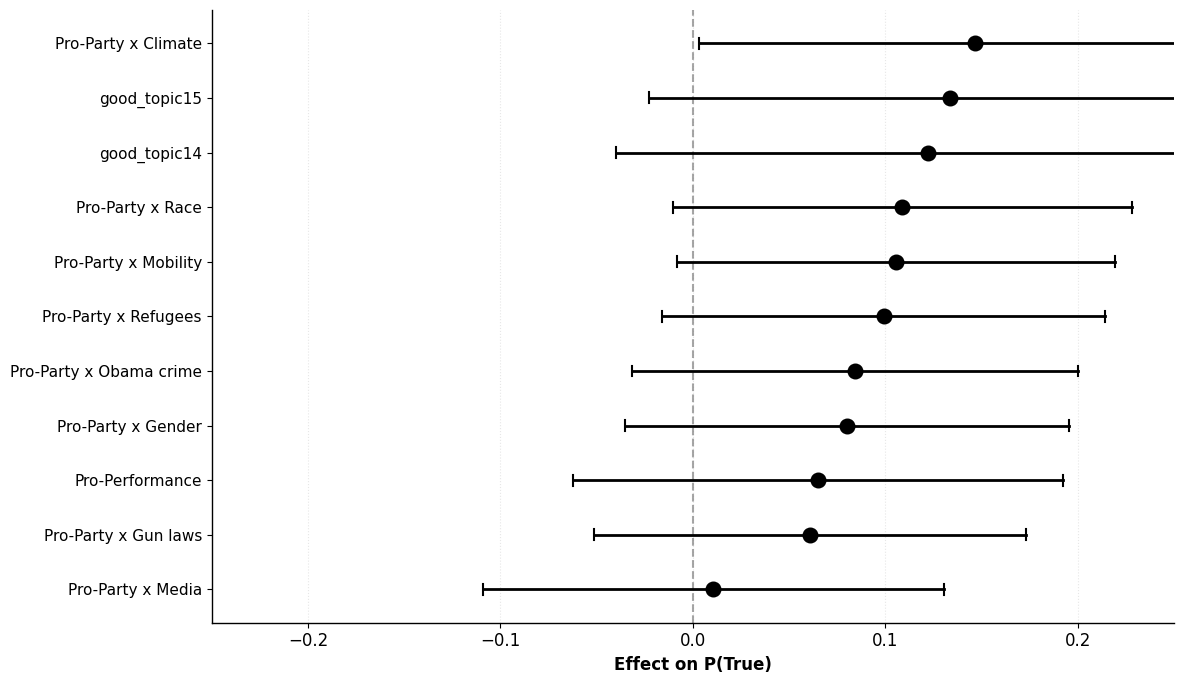

In [16]:
# Create coefplot (horizontal bar plot with CIs)
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(coef_df))

# Plot points (coefficients)
ax.scatter(coef_df['coef'], y_pos, color='black', s=100, zorder=3, edgecolors='black', linewidth=1.5)

# Plot confidence interval lines
for i, row in coef_df.iterrows():
    ax.plot([row['ci_lower'], row['ci_upper']], [i, i], color='black', linewidth=2, zorder=2)
    # Add cap lines
    ax.plot([row['ci_lower'], row['ci_lower']], [i-0.1, i+0.1], color='black', linewidth=1.5)
    ax.plot([row['ci_upper'], row['ci_upper']], [i-0.1, i+0.1], color='black', linewidth=1.5)

# Add vertical line at x=0
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# Set y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df['label'], fontsize=11)

# Set x-axis labels
ax.set_xlabel('Effect on P(True)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.25, 0.25)

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../figures/figure4.png', dpi=300, bbox_inches='tight')
print("Figure 4 saved to ../figures/figure4.png")
plt.show()

A coefficient plot is generated, illustrating the magnitude of the estimated effect of each topic on perceived veracity, along with their 95% confidence intervals. Each point represents a coefficient estimate, while the horizontal lines indicate the associated uncertainty. A vertical reference line is added at zero to distinguish between positive and negative effects. The purpose of this visualization is to illustrate how motivated reasoning varies across different topics and to highlight which topics significantly influence beliefs regarding news accuracy.

# Table 2: Motivated Reasoning Regression Results Across Specifications

In [17]:
# Prepare analysis variables and data types
bool_cols = [
    'pro_party', 'anti_party', 'true_news', 'fake_news', 'neutral_news',
    'message_greater', 'message_less', 'politicized_news', 'red_state',
    'religious_group', 'white', 'black', 'asian', 'latino', 'male'
]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# Create additional variables needed for analysis
df['anti_party_drop'] = df['anti_party']
df['pro_party_str'] = df['pro_party'] * df['abs_net_party']
df['round_number'] = df['round_number'].astype('category')
df['topic_id'] = df['topic_id'].astype('category')
df['code'] = df['code'].astype('category')

# Keep the same sample logic as the Stata specs
df['only_political_news'] = (df['pro_party'] + df['anti_party']) == 1

df[['age', 'edu', 'log_inc']] = df[['age', 'edu', 'log_inc']].astype(float)

df[['pro_party', 'anti_party', 'true_news', 'neutral_news', 'message_greater', 'message_less']].head()

/var/folders/m9/9pnpf3bd4k97457ssymqzsyr0000gn/T/ipykernel_80723/359324703.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anti_party_drop'] = df['anti_party']
/var/folders/m9/9pnpf3bd4k97457ssymqzsyr0000gn/T/ipykernel_80723/359324703.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['only_political_news'] = (df['pro_party'] + df['anti_party']) == 1


,pro_party,anti_party,true_news,neutral_news,message_greater,message_less
0,0,0,0,1,0,1
1,0,0,1,0,0,0
2,0,1,0,0,0,1
3,1,0,1,0,1,0
4,0,0,1,0,1,0


This step prepares the dataset by cleaning and standardizing the key variables used in the regression analysis. Binary indicator variables (e.g., `pro_party`, `true_news`, and demographic metrics) are converted into integers, and missing values ​​are replaced with zeros to ensure consistency in estimation. Additional variables are also constructed—such as `pro_party_str`, which captures the interaction between political leaning and its intensity, and categorical variables (e.g., `round_number`, `topic_id`, `code`) are explicitly defined to enable the inclusion of fixed effects in the regression models. The objective of this step is to ensure that all variables are correctly formatted and aligned with the empirical specifications described in the original paper.

In [18]:
# Function to run OLS regression with cluster-robust SE
def run_regression(formula, data, cluster_col='code'): 
    model = smf.ols(formula=formula, data=data).fit(
        cov_type='cluster', cov_kwds={'groups': data[cluster_col]}
    )
    return model

# Define regression specifications based on the Stata code
specs = [
    {
        'label': '(1)',
        'formula': 'prob_true ~ pro_party + net_party + C(round_number) + C(topic_id) + white + black + asian + latino + age + male + edu + red_state + religious_group + log_inc',
        'mask': df['only_political_news'],
        'question_fe': True,
        'round_fe': True,
        'subject_fe': False,
        'subject_controls': True,
        'neutral_news': False,
    },
    {
        'label': '(2)',
        'formula': 'prob_true ~ pro_party + C(round_number) + C(topic_id) + C(code)',
        'mask': df['only_political_news'],
        'question_fe': True,
        'round_fe': True,
        'subject_fe': True,
        'subject_controls': False,
        'neutral_news': False,
    },
    {
        'label': '(3)',
        'formula': 'prob_true ~ pro_party + pro_party_str + abs_net_party:C(round_number) + abs_net_party:C(topic_id) + C(round_number) + C(topic_id) + C(code)',
        'mask': df['only_political_news'],
        'question_fe': True,
        'round_fe': True,
        'subject_fe': True,
        'subject_controls': False,
        'neutral_news': False,
    },
    {
        'label': '(4)',
        'formula': 'prob_true ~ pro_party + anti_party + C(round_number) + C(code)',
        'mask': (df['net_party'] != 0) & ((df['politicized_news'] + df['neutral_news']) == 1) & ((df['message_greater'] + df['message_less']) == 1),
        'question_fe': False,
        'round_fe': True,
        'subject_fe': True,
        'subject_controls': False,
        'neutral_news': True,
    },
    {
        'label': '(5)',
        'formula': 'prob_true ~ true_news + C(round_number) + C(topic_id) + C(code)',
        'mask': df['only_political_news'],
        'question_fe': True,
        'round_fe': True,
        'subject_fe': True,
        'subject_controls': False,
        'neutral_news': False,
    },
    {
        'label': '(6)',
        'formula': 'prob_true ~ pro_party + true_news + C(round_number) + C(topic_id) + C(code)',
        'mask': df['only_political_news'],
        'question_fe': True,
        'round_fe': True,
        'subject_fe': True,
        'subject_controls': False,
        'neutral_news': False,
    },
]

# Run regressions and store results
for spec in specs:
    data = df.loc[spec['mask'], :].copy()
    spec['model'] = run_regression(spec['formula'], data)
    spec['n'] = len(data)
    spec['mean'] = data['prob_true'].mean()

specs


[{'label': '(1)',
  'formula': 'prob_true ~ pro_party + net_party + C(round_number) + C(topic_id) + white + black + asian + latino + age + male + edu + red_state + religious_group + log_inc',
  'mask': 0        False
  1        False
  2         True
  3         True
  4        False
           ...  
  13813     True
  13814     True
  13815    False
  13816     True
  13817    False
  Name: only_political_news, Length: 13818, dtype: bool,
  'question_fe': True,
  'round_fe': True,
  'subject_fe': False,
  'subject_controls': True,
  'neutral_news': False,
  'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1374c7620>,
  'n': 7902,
  'mean': np.float64(0.5741964080422678)},
 {'label': '(2)',
  'formula': 'prob_true ~ pro_party + C(round_number) + C(topic_id) + C(code)',
  'mask': 0        False
  1        False
  2         True
  3         True
  4        False
           ...  
  13813     True
  13814     True
  13815    False
  13816     True
  13817    Fals

An ordinary least squares (OLS) regression function incorporating cluster-robust standard errors was defined and made reusable, and multiple regression models were specified. Each model specification differed in terms of the control variables and fixed effects included—such as question-level, round-level, and subject-level fixed effects. The purpose of defining these multiple model specifications was to test the robustness of the main results under varying modeling assumptions and to replicate the structure of the regression tables reported in the original paper.

In [19]:
# Prepare table data for display
rows = [
    'Pro-Party News',
    'Pro-Party News SE',
    'Partisanship x Pro-Party',
    'Partisanship x Pro-Party SE',
    'Anti-Party News',
    'Anti-Party News SE',
    'True News',
    'True News SE',
    'Question FE',
    'Round FE',
    'Subject FE',
    'Subject controls',
    'Neutral News',
    'Observations',
    'R2',
    'Mean',
]

# Create a dictionary to hold table data
table_data = {spec['label']: [] for spec in specs}

# Fill in the table data from the regression results
for spec in specs:
    model = spec['model']
    table_data[spec['label']].extend([
        model.params.get('pro_party', np.nan),
        model.bse.get('pro_party', np.nan),
        model.params.get('pro_party_str', np.nan),
        model.bse.get('pro_party_str', np.nan),
        model.params.get('anti_party', np.nan),
        model.bse.get('anti_party', np.nan),
        model.params.get('true_news', np.nan),
        model.bse.get('true_news', np.nan),
        'Yes' if spec['question_fe'] else 'No',
        'Yes' if spec['round_fe'] else 'No',
        'Yes' if spec['subject_fe'] else 'No',
        'Yes' if spec['subject_controls'] else 'No',
        'Yes' if spec['neutral_news'] else 'No',
        spec['n'],
        model.rsquared,
        spec['mean'],
    ])

results_display = pd.DataFrame(table_data, index=rows)
results_display

/Users/melodyzmac/Library/Python/3.14/lib/python/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


,(1),(2),(3),(4),(5),(6)
Pro-Party News,0.092002,0.088274,0.040529,0.03693,NaN,0.077403
Pro-Party News SE,0.006243,0.950634,487.40553,0.006756,NaN,0.006882
Partisanship x Pro-Party,NaN,NaN,0.099175,NaN,NaN,NaN
Partisanship x Pro-Party SE,NaN,NaN,451.428877,NaN,NaN,NaN
Anti-Party News,NaN,NaN,NaN,-0.048313,NaN,NaN
Anti-Party News SE,NaN,NaN,NaN,0.007135,NaN,NaN
True News,NaN,NaN,NaN,NaN,-0.058812,-0.033755
True News SE,NaN,NaN,NaN,NaN,NaN,0.006583
Question FE,Yes,Yes,Yes,No,Yes,Yes
Round FE,Yes,Yes,Yes,Yes,Yes,Yes


The collected regression results are converted into a pandas DataFrame for presentation. Each column corresponds to a specific model specification, while each row represents a coefficient, standard error, or model feature. The objective of this step is to present the results in a clean and interpretable format, resembling a standard academic regression table. Thereby facilitating the analysis of the existence and robustness of motivated reasoning effects.

# Table 3: Effects of Partisanship and Polarization on Belief Updating

In [20]:
# Prepare analysis variables and data types for Table 3
bool_cols = [
    'pro_party', 'anti_party', 'true_news', 'fake_news', 'neutral_news',
    'message_greater', 'message_less', 'politicized_news', 'red_state',
    'religious_group', 'white', 'black', 'asian', 'latino', 'male',
    'polarizing'
]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# Use the same categorical fixed-effect variables as in the Stata code
for col in ['round_number', 'topic_id', 'code']:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Make sure the key outcome is numeric
if 'change_guess_message' in df.columns:
    df['change_guess_message'] = pd.to_numeric(df['change_guess_message'], errors='coerce')

# Sample selection used in Table 3
if 'pro_party' in df.columns and 'anti_party' in df.columns:
    df['only_political_news'] = (df['pro_party'] + df['anti_party']) == 1

# Show the relevant column types and a quick preview
cols_to_check = ['pro_party', 'anti_party', 'polarizing', 'prob_true', 'change_guess_message', 'round_number', 'topic_id', 'code']
print(df[cols_to_check].dtypes)
df[cols_to_check].head()

pro_party                  int64
anti_party                 int64
polarizing                 int64
prob_true                float64
change_guess_message     float64
round_number            category
topic_id                category
code                    category
dtype: object


,pro_party,anti_party,polarizing,prob_true,change_guess_message,round_number,topic_id,code
0,0,0,1,0.0,0.0,12,11,00d576h7
1,0,0,0,1.0,NaN,11,12,00d576h7
2,0,1,0,0.5,0.0,2,4,00d576h7
3,1,0,0,0.5,0.0,4,5,00d576h7
4,0,0,1,0.5,0.0,13,13,00d576h7


To prepare the dataset for replicating Table 3, variables related to belief updating were cleaned and standardized. Binary variables—such as `pro_party`, `anti_party`, and `polarizing`—were converted into numerical indicators to ensure compatibility with regression analysis. Fixed-effects variables (`round_number`, `topic_id`, and `code`) were explicitly cast as categorical types to facilitate their inclusion as fixed effects in the regression models. Furthermore, the outcome variable `change_guess_message` was coerced into a numerical format to prevent estimation errors. Sample restrictions were also applied to focus exclusively on observations exhibiting explicit partisanship, consistent with the original paper. The objective of this step was to ensure that the dataset conforms to the structural requirements and underlying assumptions necessary for the empirical specifications presented in Table 3.

In [21]:
def run_regression(formula, data, cluster_col='code'):
    # Fit OLS and then re-fit the same sample with cluster-robust standard errors.
    ols_result = smf.ols(formula=formula, data=data).fit()
    row_labels = ols_result.model.data.row_labels
    used_data = data.loc[row_labels, :].copy()
    model = smf.ols(formula=formula, data=used_data).fit(
        cov_type='cluster', cov_kwds={'groups': used_data[cluster_col]}
    )
    return model

# Define regression specifications for Table 3
specs = [
    {
        'label': '(1)',
        'formula': 'change_guess_message ~ pro_party',
        'mask': df['only_political_news'],
    },
    {
        'label': '(2)',
        'formula': 'change_guess_message ~ polarizing',
        'mask': df['only_political_news'],
    },
    {
        'label': '(3)',
        'formula': 'change_guess_message ~ pro_party + polarizing',
        'mask': df['only_political_news'],
    },
    {
        'label': '(4)',
        'formula': 'change_guess_message ~ pro_party + prob_true',
        'mask': df['only_political_news'],
    },
    {
        'label': '(5)',
        'formula': 'change_guess_message ~ polarizing + prob_true',
        'mask': df['only_political_news'],
    },
    {
        'label': '(6)',
        'formula': 'change_guess_message ~ pro_party + polarizing + prob_true',
        'mask': df['only_political_news'],
    },
]

# Run regressions and store results
for spec in specs:
    data = df.loc[spec['mask'], :].copy()
    spec['model'] = run_regression(spec['formula'], data)
    spec['n'] = len(data)
    spec['mean'] = data['change_guess_message'].mean()

specs

[{'label': '(1)',
  'formula': 'change_guess_message ~ pro_party',
  'mask': 0        False
  1        False
  2         True
  3         True
  4        False
           ...  
  13813     True
  13814     True
  13815    False
  13816     True
  13817    False
  Name: only_political_news, Length: 13818, dtype: bool,
  'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x13741a140>,
  'n': 7902,
  'mean': np.float64(0.6582619339045288)},
 {'label': '(2)',
  'formula': 'change_guess_message ~ polarizing',
  'mask': 0        False
  1        False
  2         True
  3         True
  4        False
           ...  
  13813     True
  13814     True
  13815    False
  13816     True
  13817    False
  Name: only_political_news, Length: 13818, dtype: bool,
  'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x137373150>,
  'n': 7902,
  'mean': np.float64(0.6582619339045288)},
 {'label': '(3)',
  'formula': 'change_guess_message ~ pro_party + po

The core regression analysis used to replicate Table 3, which examines how partisan bias and information polarization influence belief updating (`change_guess_message`) has been implemented. First, a regression function was defined to estimate Ordinary Least Squares (OLS) models using individual-level clustered robust standard errors. This function is intentionally designed to execute the regression in two stages: it first performs an initial OLS estimation to identify the exact sample of observations remaining after handling missing values; it then re-estimates the model using this identical sample, applying the clustered standard errors. This approach ensures consistency in estimation and avoids discrepancies that might otherwise arise from automatic row deletion.

Next, a set of regression specifications (`specs`) was defined to mirror the structure of Table 3 in the original paper. Each specification represents a distinct model, progressively incorporating key explanatory variables such as `pro_party` (alignment with partisan beliefs), `polarizing` (whether the message is polarizing), and `prob_true` (the baseline belief regarding the veracity of the message). This stepwise design enables us to isolate the individual and joint effects of these variables on belief updating.

The code then iterates through each specification, applying consistent sample restrictions (limiting the analysis to political news observations only) and estimating the corresponding regression models. For each model, it stores the fitted regression results, the number of observations, and the mean of the dependent variable. This structured storage of results facilitates the construction of the final regression table and ensures comparability across specifications.

The objective of this program is to faithfully reproduce the empirical strategy of the original study while maintaining consistency in sample selection and statistical inference. By employing clustered standard errors and carefully controlling for baseline beliefs, the analysis aims to provide credible estimates regarding how partisan alignment and information characteristics influence belief-updating behavior.

In [22]:
# Prepare table data for display
rows = [
    'Pro-Party News',
    'Pro-Party News SE',
    'Polarizing News',
    'Polarizing News SE',
    'P(True)',
    'P(True) SE',
    'Question FE',
    'Round FE',
    'Subject FE',
    'Observations',
    'R2',
    'Mean',
]

table_data = {spec['label']: [] for spec in specs}

# Extract coefficients, standard errors, and other info for each specification
for spec in specs:
    model = spec['model']
    table_data[spec['label']].extend([
        model.params.get('pro_party', np.nan),
        model.bse.get('pro_party', np.nan),
        model.params.get('polarizing', np.nan),
        model.bse.get('polarizing', np.nan),
        model.params.get('prob_true', np.nan),
        model.bse.get('prob_true', np.nan),
        'Yes',
        'Yes',
        'Yes',
        spec['n'],
        model.rsquared,
        spec['mean'],
    ])

results_display = pd.DataFrame(table_data, index=rows)
results_display

,(1),(2),(3),(4),(5),(6)
Pro-Party News,0.122109,NaN,0.112326,0.020467,NaN,0.023749
Pro-Party News SE,0.01934,NaN,0.019736,0.017696,NaN,0.017969
Polarizing News,NaN,0.067859,0.041167,NaN,-0.009812,-0.014949
Polarizing News SE,NaN,0.01818,0.018313,NaN,0.016196,0.016372
P(True),NaN,NaN,NaN,1.137526,1.148039,1.140555
P(True) SE,NaN,NaN,NaN,0.055112,0.054077,0.05552
Question FE,Yes,Yes,Yes,Yes,Yes,Yes
Round FE,Yes,Yes,Yes,Yes,Yes,Yes
Subject FE,Yes,Yes,Yes,Yes,Yes,Yes
Observations,7902,7902,7902,7902,7902,7902


This step converts the collected regression outputs into a pandas DataFrame for presentation purposes. Each column represents a specific model specification, while each row corresponds to a coefficient, standard error, or model feature. The objective of this step is to display the regression results in a concise, publication-style tabular format, thereby facilitating the interpretation of how partisanship and polarization influence belief updating.